<a href="https://colab.research.google.com/github/cailuj/TCC/blob/main/ajustes_explicabilidade_densenet121.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, applications
from sklearn.model_selection import GroupShuffleSplit
from google.colab import drive

drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/MINI-DDSM/'
EXCEL_PATH = os.path.join(BASE_PATH, 'DataWMask.xlsx')
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CHANNELS = 3
SEED = 42

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel(EXCEL_PATH)

df['fullPath'] = df['fullPath'].str.replace('\\', '/', regex=False)
df['Tumour_Contour'] = df['Tumour_Contour'].str.replace('\\', '/', regex=False)

def extract_patient_id(path):
    parts = path.split('/')
    return parts[1] if len(parts) > 1 else 'unknown'

df['patient_id'] = df['fullPath'].apply(extract_patient_id)

class_map = {'Normal': 0, 'Benign': 1, 'Cancer': 2}
df['label'] = df['Status'].map(class_map)

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_val_idx, test_idx = next(gss_test.split(df, df['label'], groups=df['patient_id']))

train_val_df = df.iloc[train_val_idx]
test_df = df.iloc[test_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(gss_val.split(train_val_df, train_val_df['label'], groups=train_val_df['patient_id']))

train_df = train_val_df.iloc[train_idx]
val_df = train_val_df.iloc[val_idx]

print(f'Treino: {len(train_df)} | Val: {len(val_df)} | Teste: {len(test_df)}')

Treino: 4968 | Val: 1236 | Teste: 1604


In [ ]:
def load_and_preprocess(path, label):
    full_path = tf.strings.join([BASE_PATH, path])
    img = tf.io.read_file(full_path)
    img = tf.image.decode_jpeg(img, channels=CHANNELS)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def create_ds(dataframe, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((dataframe['fullPath'].values, dataframe['label'].values))
    if shuffle:
        ds = ds.shuffle(len(dataframe))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = create_ds(train_df)
val_ds = create_ds(val_df, shuffle=False)
test_ds = create_ds(test_df, shuffle=False)

In [ ]:
base_model = applications.DenseNet121(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

checkpoint = callbacks.ModelCheckpoint('best_densenet121_model.keras', save_best_only=True, monitor='val_loss')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint]
)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 816s 4s/step - accuracy: 0.3458 - loss: 1.3604 - val_accuracy: 0.3722 - val_loss: 1.1563
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 20s 129ms/step - accuracy: 0.4076 - loss: 1.1676 - val_accuracy: 0.4005 - val_loss: 1.1351
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - accuracy: 0.4716 - loss: 1.0748 - val_accuracy: 0.4620 - val_loss: 1.0408
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 20s 128ms/step - accuracy: 0.4936 - loss: 1.0202 - val_accuracy: 0.5097 - val_loss: 0.9748
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 20s 129ms/step - accuracy: 0.5155 - loss: 0.9809 - val_accuracy: 0.5283 - val_loss: 0.9223
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 20s 128ms/step - accuracy: 0.5395 - loss: 0.9385 - val_accuracy: 0.5680 - val_loss: 0.8856
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - accuracy: 0.5622 - loss: 0.9108 - val_accuracy: 0.5712 - val_loss: 0.8628
Epoch 8/50
156/156 ━━━━━━━━━━━━━━━

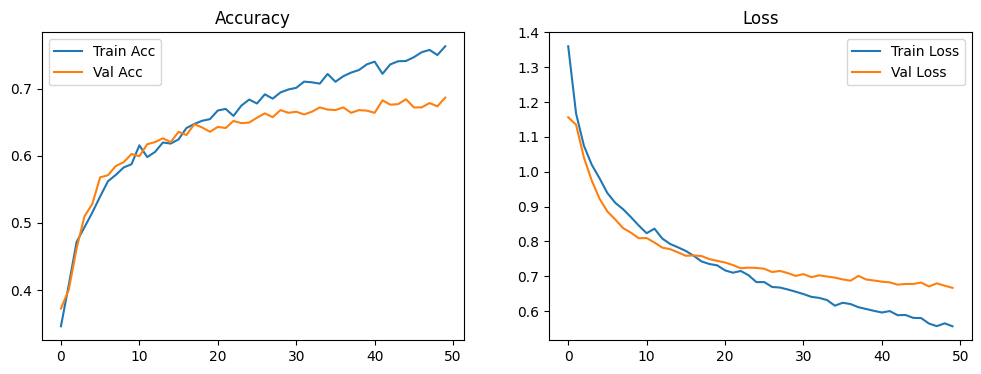

51/51 ━━━━━━━━━━━━━━━━━━━━ 187s 4s/step - accuracy: 0.7026 - loss: 0.6410

Acurácia no Teste (Holdout): 0.7026

Calculando métricas detalhadas...
51/51 ━━━━━━━━━━━━━━━━━━━━ 27s 308ms/step

Relatório de Classificação:
              precision    recall  f1-score   support

      Normal       0.92      0.78      0.85       588
      Benign       0.61      0.66      0.63       516
      Cancer       0.60      0.65      0.62       500

    accuracy                           0.70      1604
   macro avg       0.71      0.70      0.70      1604
weighted avg       0.72      0.70      0.71      1604



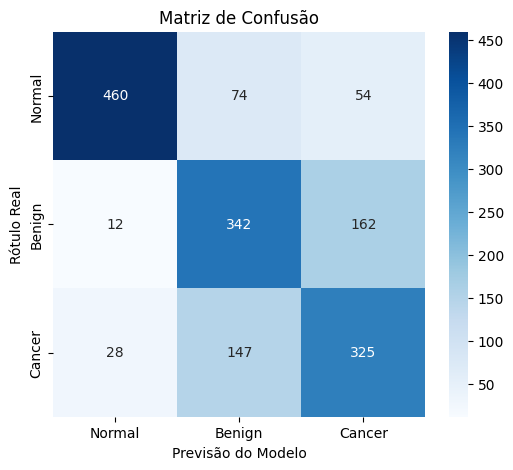

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

test_loss, test_acc = model.evaluate(test_ds)
print(f'\nAcurácia no Teste (Holdout): {test_acc:.4f}')

print("\nCalculando métricas detalhadas...")
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nRelatório de Classificação:")
target_names = ['Normal', 'Benign', 'Cancer']
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Matriz de Confusão')
plt.ylabel('Rótulo Real')
plt.xlabel('Previsão do Modelo')
plt.show()

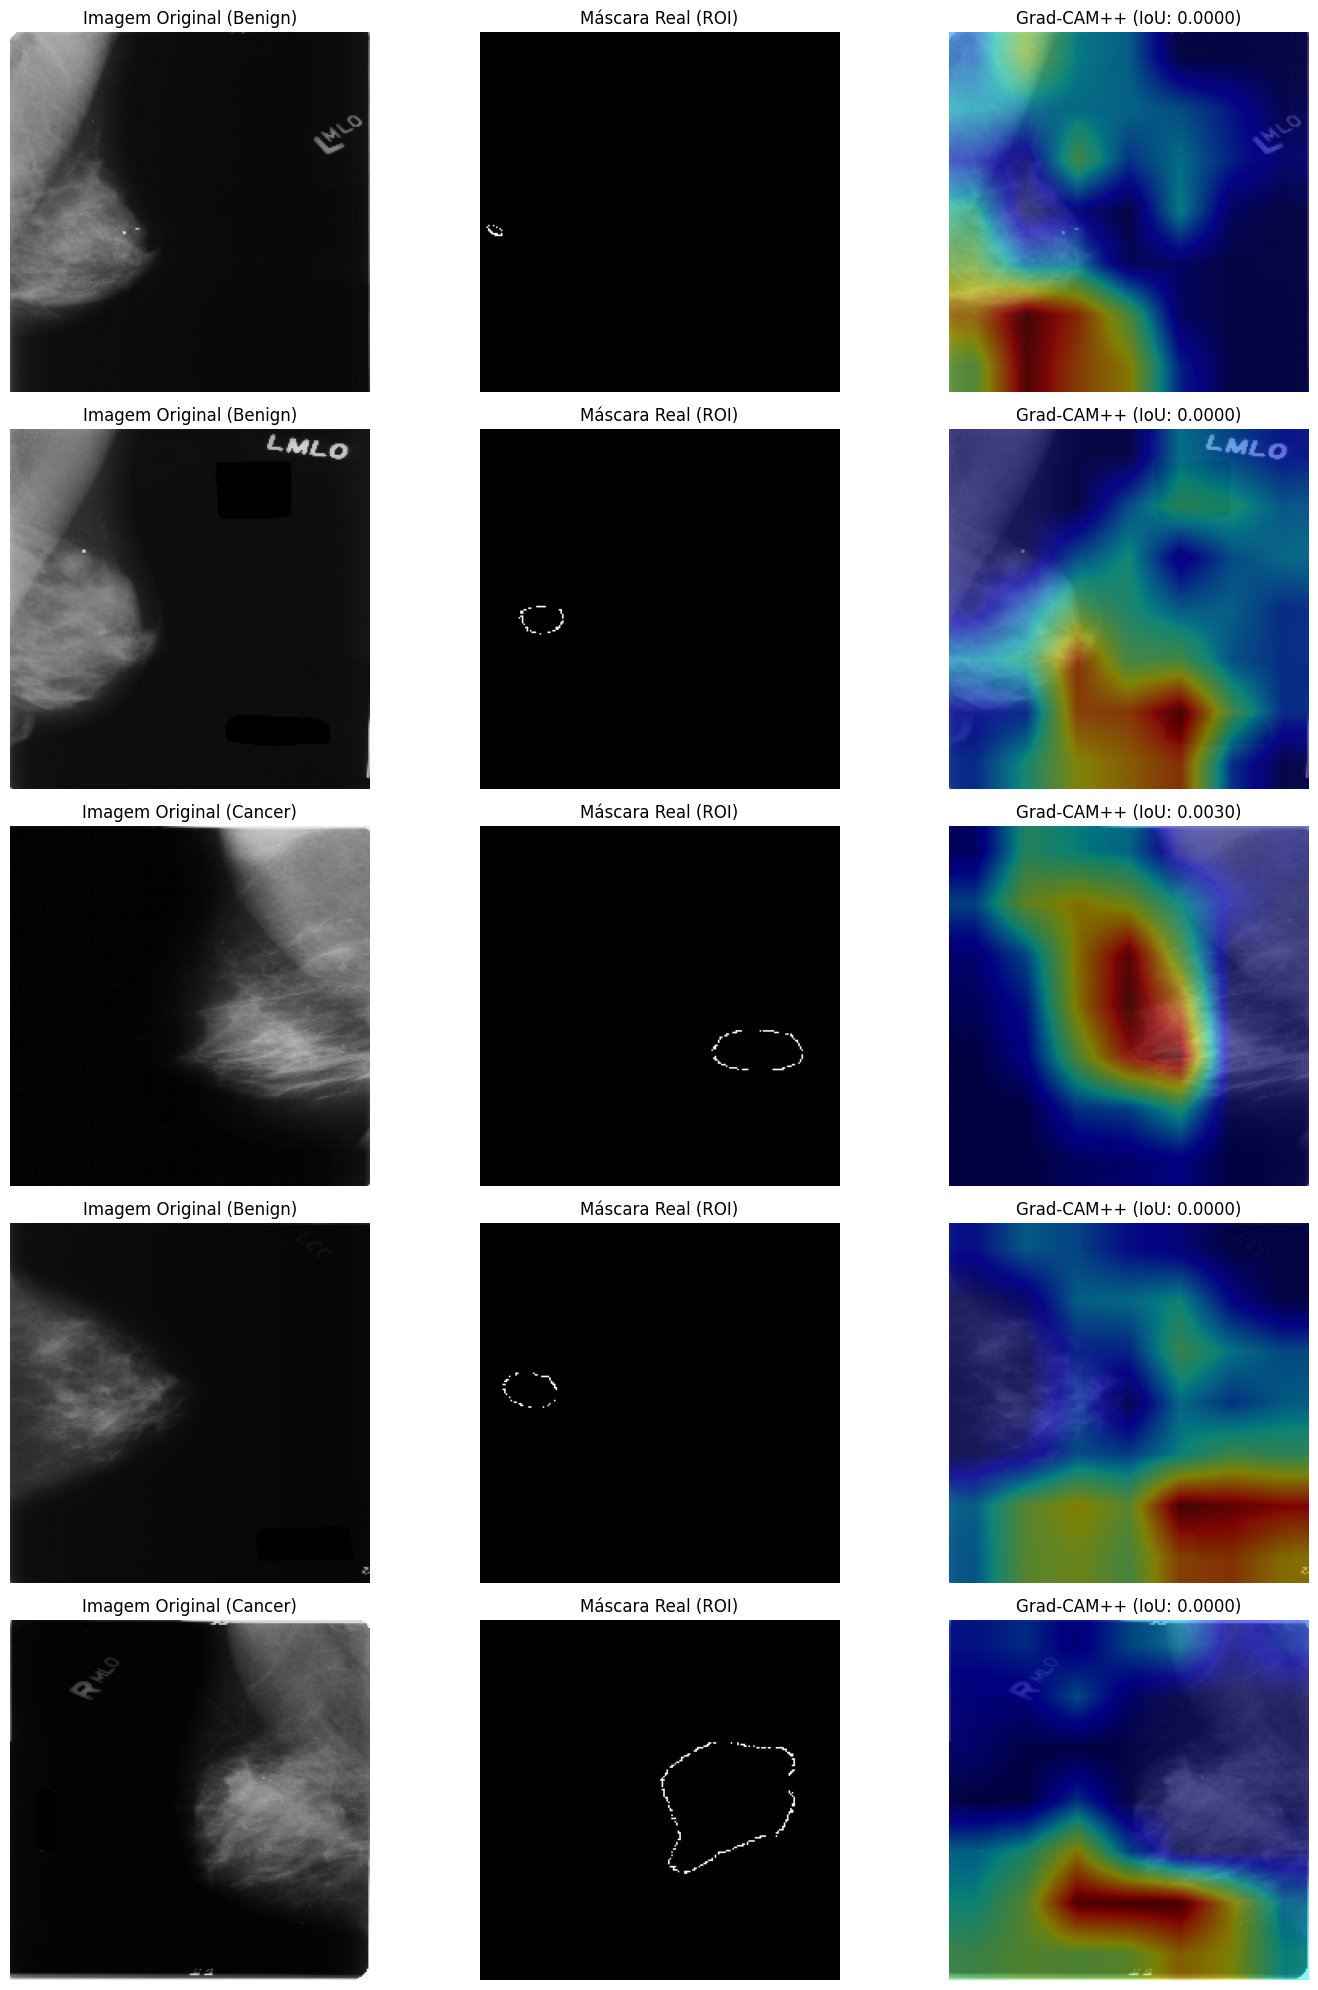

In [ ]:
import cv2
import numpy as np

def get_gradcam_plus_plus(model, img_array, last_conv_layer_name):
    base_model = model.layers[0]
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    res_output = last_conv_layer.output

    x = model.layers[1](base_model.output)
    for layer in model.layers[2:]:
        x = layer(x)

    grad_model = tf.keras.models.Model([base_model.input], [res_output, x])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(tf.multiply(weights, conv_outputs), axis=-1)

    heatmap = np.maximum(heatmap, 0) / (np.max(heatmap) + 1e-10)
    return heatmap[0]

def calculate_iou(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    if np.sum(union) == 0: return 0
    return np.sum(intersection) / np.sum(union)

test_with_masks = test_df[(test_df['Status'] != 'Normal') & (test_df['Tumour_Contour'] != '-')]

if len(test_with_masks) >= 5:
    sample_rows = test_with_masks.sample(5, random_state=SEED)

    fig, axes = plt.subplots(5, 3, figsize=(15, 20))

    for i, (_, row) in enumerate(sample_rows.iterrows()):
        img_path = os.path.join(BASE_PATH, row['fullPath'])
        mask_path = os.path.join(BASE_PATH, row['Tumour_Contour'])

        img_raw = tf.io.read_file(img_path)
        img_decoded = tf.image.decode_jpeg(img_raw, channels=3)
        img_resized = tf.image.resize(img_decoded, IMG_SIZE)
        img_normalized = tf.cast(img_resized, tf.float32) / 255.0
        img_batch = tf.expand_dims(img_normalized, 0)

        try:
            heatmap = get_gradcam_plus_plus(model, img_batch, 'relu')

            mask_img = cv2.imread(mask_path, 0)
            if mask_img is not None:
                mask = cv2.resize(mask_img, IMG_SIZE) > 0
                heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
                heatmap_bin = heatmap_resized > 0.5
                iou_score = calculate_iou(mask, heatmap_bin)

                axes[i, 0].imshow(img_normalized)
                axes[i, 0].set_title(f'Imagem Original ({row["Status"]})')
                axes[i, 0].axis('off')

                axes[i, 1].imshow(mask, cmap='gray')
                axes[i, 1].set_title('Máscara Real (ROI)')
                axes[i, 1].axis('off')

                axes[i, 2].imshow(img_normalized)
                axes[i, 2].imshow(heatmap_resized, alpha=0.5, cmap='jet')
                axes[i, 2].set_title(f'Grad-CAM++ (IoU: {iou_score:.4f})')
                axes[i, 2].axis('off')
            else:
                print(f'Erro ao carregar o arquivo de máscara para a amostra {i+1}.')
        except Exception as e:
            print(f'Erro na execução do Grad-CAM++ para a amostra {i+1}: {e}')

    plt.tight_layout()
    plt.show()
else:
    print('Nenhuma amostra com máscara encontrada no conjunto de teste.')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

sample_df = test_df[(test_df['Status'] != 'Normal') & (test_df['Tumour_Contour'] != '-')].sample(5, random_state=SEED)

sample_images = []
sample_labels = []
sample_masks = []

for _, row in sample_df.iterrows():
    img_path = os.path.join(BASE_PATH, row['fullPath'])
    img_raw = tf.io.read_file(img_path)
    img_decoded = tf.image.decode_jpeg(img_raw, channels=3)
    img_resized = tf.image.resize(img_decoded, IMG_SIZE)
    img_normalized = tf.cast(img_resized, tf.float32) / 255.0
    sample_images.append(img_normalized.numpy())
    sample_labels.append(row['label'])

    mask_path = os.path.join(BASE_PATH, row['Tumour_Contour'])
    mask_raw = cv2.imread(mask_path, 0)
    if mask_raw is not None:
        mask_resized = cv2.resize(mask_raw, IMG_SIZE)
    else:
        mask_resized = np.zeros(IMG_SIZE)
    sample_masks.append(mask_resized)

sample_images = np.array(sample_images)
sample_labels = np.array(sample_labels)
sample_masks = np.array(sample_masks)
print(f'Selecionadas {len(sample_images)} imagens com máscaras para explicação.')

Selecionadas 5 imagens com máscaras para explicação.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 22.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=58f8ba0e9ad2bc14d02b70f67aebb3da7504512c9eac39ca1c8279dd1efd0700
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━

  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━

  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━

  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━

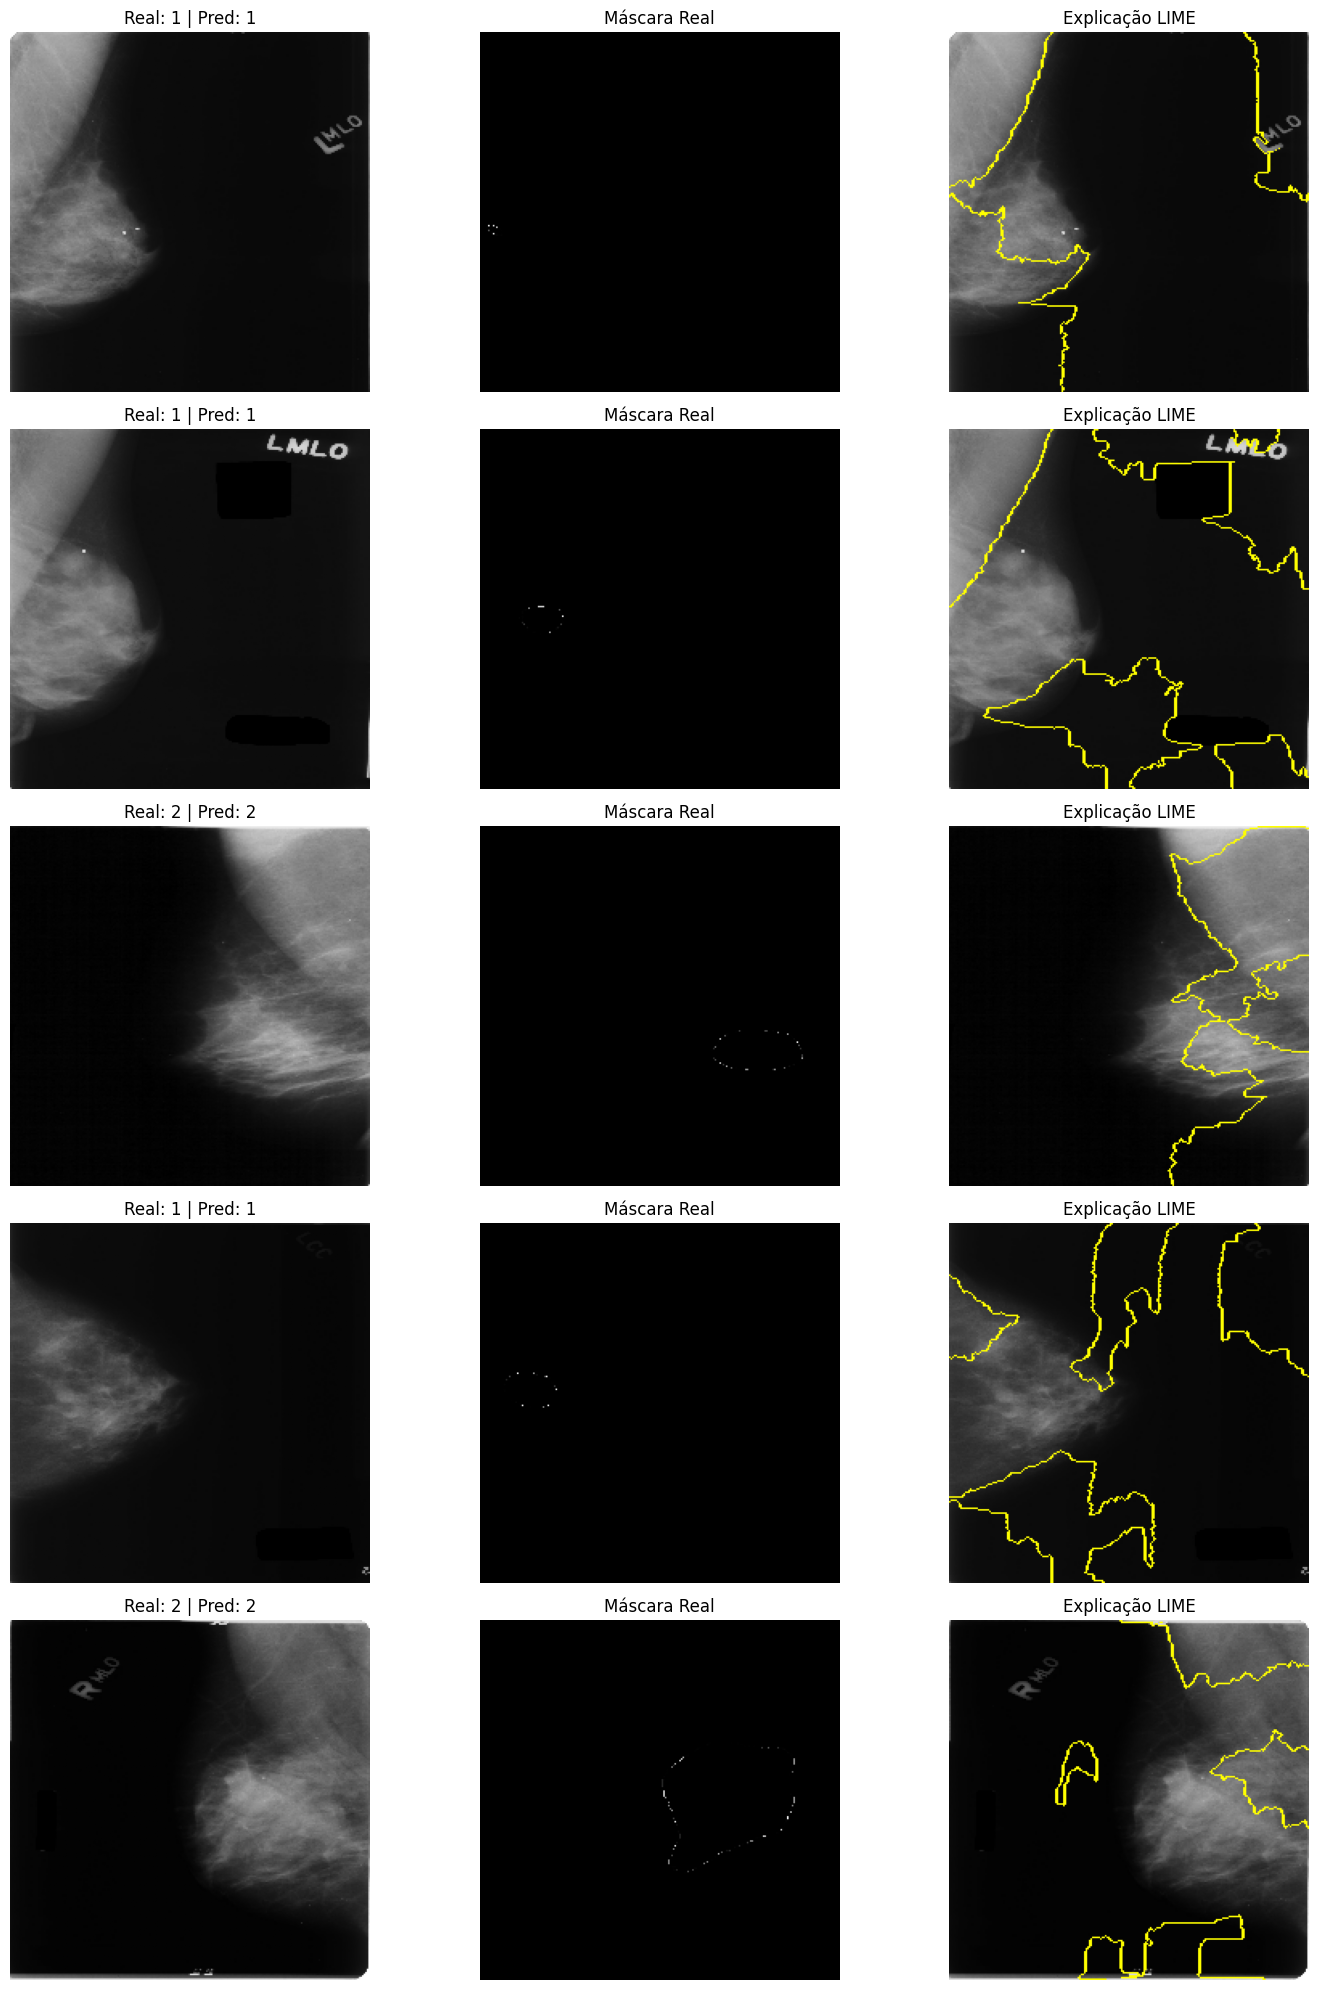

In [ ]:
!pip install lime
from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer = lime_image.LimeImageExplainer()

fig, axes = plt.subplots(5, 3, figsize=(15, 20))
for i in range(5):
    img = sample_images[i]
    label = sample_labels[i]
    mask_img = sample_masks[i]

    explanation = explainer.explain_instance(
        img.astype('double'),
        model.predict,
        top_labels=3,
        hide_color=0,
        num_samples=500
    )

    preds = model.predict(np.expand_dims(img, axis=0))
    pred_class = np.argmax(preds)

    temp, mask = explanation.get_image_and_mask(
        pred_class,
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Real: {label} | Pred: {pred_class}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask_img, cmap='gray')
    axes[i, 1].set_title('Máscara Real')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(mark_boundaries(temp, mask))
    axes[i, 2].set_title('Explicação LIME')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

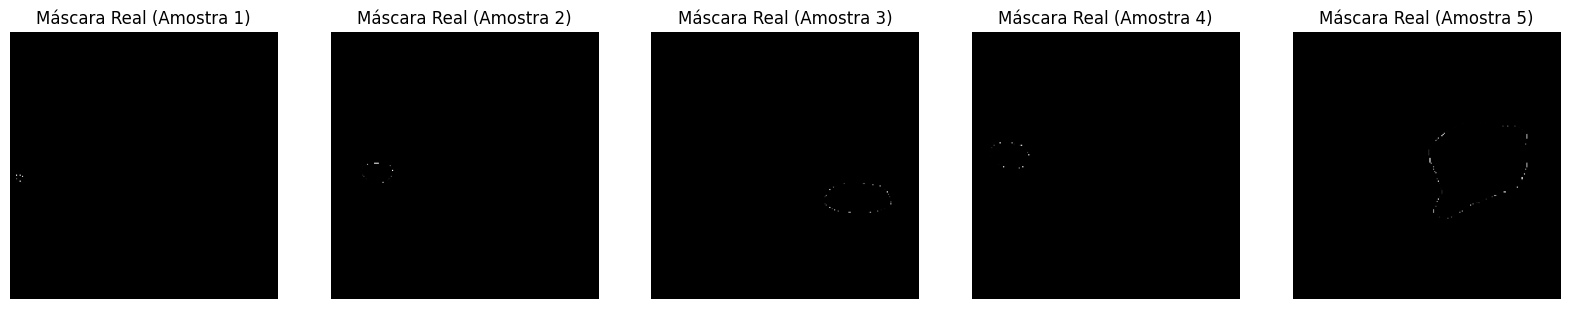

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_427
Received: inputs=['Tensor(shape=(5, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_427
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


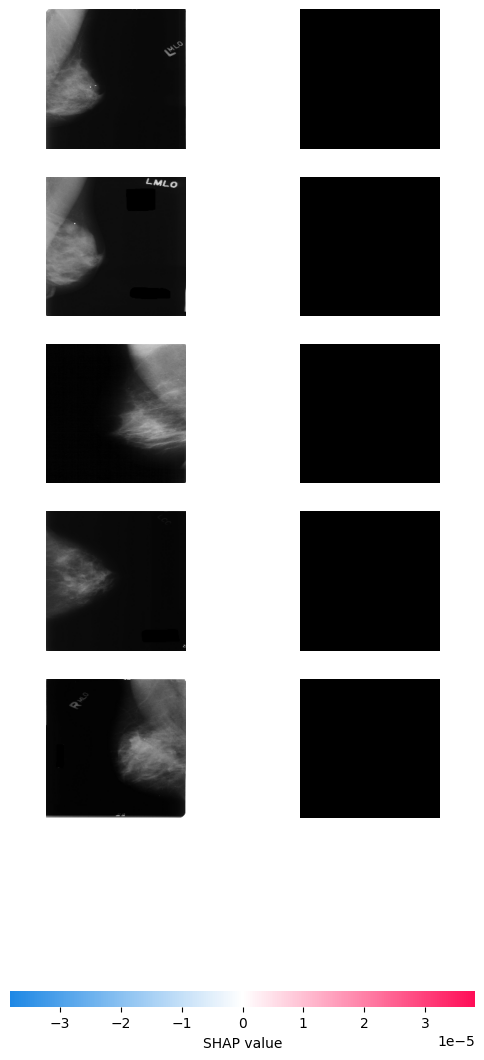

In [ ]:
import shap
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    axes[i].imshow(sample_masks[i], cmap='gray')
    axes[i].set_title(f'Máscara Real (Amostra {i+1})')
    axes[i].axis('off')
plt.show()

explainer_shap = shap.GradientExplainer(model, sample_images)

shap_values = explainer_shap.shap_values(sample_images)

shap.image_plot(shap_values, sample_images)

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.ndimage import center_of_mass
import tensorflow as tf

OUT_DIR = './xai_diagnostic_outputs'
os.makedirs(OUT_DIR, exist_ok=True)
TARGET_LAYER_NAME = 'relu'

def apply_transformation(img, t_type):
    if t_type == 'original':
        return img
    elif t_type == 'rotate_15':
        center = (img.shape[1]//2, img.shape[0]//2)
        M = cv2.getRotationMatrix2D(center, 15, 1.0)
        return cv2.warpAffine(img, M, (img.shape[1], img.shape[0]))
    elif t_type == 'noise':
        noise = np.random.normal(0, 0.05, img.shape)
        return np.clip(img + noise, 0, 1)
    elif t_type == 'brightness':
        return np.clip(img * 1.2, 0, 1)
    return img

def calc_metrics(orig_hm, trans_hm):
    corr, _ = pearsonr(orig_hm.flatten(), trans_hm.flatten())

    bin_orig = orig_hm > 0.5
    bin_trans = trans_hm > 0.5
    intersection = np.logical_and(bin_orig, bin_trans).sum()
    union = np.logical_or(bin_orig, bin_trans).sum()
    iou = intersection / union if union > 0 else 0.0

    cm_orig = center_of_mass(orig_hm)
    cm_trans = center_of_mass(trans_hm)
    if not np.isnan(cm_orig).any() and not np.isnan(cm_trans).any():
        dist = np.linalg.norm(np.array(cm_orig) - np.array(cm_trans))
    else:
        dist = np.nan

    return corr, iou, dist

transformations = ['original', 'rotate_15', 'noise', 'brightness']
results = []

for i, img in enumerate(sample_images):
    img_batch_orig = np.expand_dims(img, axis=0)
    pred_orig = np.argmax(model.predict(img_batch_orig, verbose=0))
    hm_orig = get_gradcam_plus_plus(model, img_batch_orig, TARGET_LAYER_NAME)
    hm_orig_resized = cv2.resize(hm_orig, (IMG_SIZE[1], IMG_SIZE[0]))

    fig, axes = plt.subplots(len(transformations), 3, figsize=(12, 4 * len(transformations)))
    fig.suptitle(f'Diagnóstico XAI - Amostra {i+1} (Predição Original: {pred_orig})', fontsize=16)

    for j, t_type in enumerate(transformations):
        trans_img = apply_transformation(img, t_type)
        img_batch_trans = np.expand_dims(trans_img, axis=0)

        pred_trans = np.argmax(model.predict(img_batch_trans, verbose=0))
        hm_trans = get_gradcam_plus_plus(model, img_batch_trans, TARGET_LAYER_NAME)
        hm_trans_resized = cv2.resize(hm_trans, (IMG_SIZE[1], IMG_SIZE[0]))

        same_pred = int(pred_orig == pred_trans)

        if t_type == 'original':
            corr, iou, dist = 1.0, 1.0, 0.0
        else:
            corr, iou, dist = calc_metrics(hm_orig_resized, hm_trans_resized)

        results.append({
            'sample_idx': i,
            'transformation': t_type,
            'pred_class': pred_trans,
            'same_prediction_as_original': same_pred,
            'heatmap_corr_vs_original': corr,
            'heatmap_iou_vs_original': iou,
            'heatmap_center_distance_vs_original': dist
        })

        axes[j, 0].imshow(trans_img)
        axes[j, 0].set_title(f'{t_type}\nPred: {pred_trans}')
        axes[j, 0].axis('off')

        axes[j, 1].imshow(hm_trans_resized, cmap='jet')
        axes[j, 1].set_title(f'Heatmap\nCorr: {corr:.2f} | IoU: {iou:.2f}')
        axes[j, 1].axis('off')

        axes[j, 2].imshow(trans_img)
        axes[j, 2].imshow(hm_trans_resized, cmap='jet', alpha=0.5)
        axes[j, 2].set_title('Overlay')
        axes[j, 2].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'sample_{i}_panel.png'))
    plt.close()

df_metrics = pd.DataFrame(results)
df_metrics.to_csv(os.path.join(OUT_DIR, 'diagnostic_metrics.csv'), index=False)

summary = df_metrics.groupby('transformation').agg({
    'same_prediction_as_original': 'mean',
    'heatmap_corr_vs_original': 'mean',
    'heatmap_iou_vs_original': 'mean',
    'heatmap_center_distance_vs_original': 'mean'
}).reset_index()
summary.to_csv(os.path.join(OUT_DIR, 'diagnostic_summary.csv'), index=False)

print(f"Diagnóstico concluído! Resultados salvos em: {OUT_DIR}")
display(summary)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Diagnóstico concluído! Resultados salvos em: ./xai_diagnostic_outputs


,transformation,same_prediction_as_original,heatmap_corr_vs_original,heatmap_iou_vs_original,heatmap_center_distance_vs_original
0,brightness,1.0,0.635312,0.494300,30.434155
1,noise,0.4,0.240366,0.247821,47.959585
2,original,1.0,1.000000,1.000000,0.000000
3,rotate_15,0.8,0.286556,0.268868,39.554114
